# 00 — Data Contract & Panel

This notebook is the **foundation the entire repo trusts**. It locks the
universe, the dates, the frequency, and the train/test split, and builds the
`Panel` that every later model reads from. Get this right once and every
comparison downstream inherits a fair, fixed playing field.

Nothing here forecasts or allocates. It only defines *what data exists and on
what terms* — the contract.

## Why a contract, not just a loader

A comparison is only fair if every method sees **identical** data on identical
terms. If each notebook loaded its own dates or universe, the comparison would
silently drift. So the universe, dates, costs, and conventions live in one
place — `maplab.contract` — and everything imports from it.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import maplab as ml
from maplab import Panel, apply_style

apply_style()
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## The universe — 29 instruments across 6 groups

Grouping is explicit and load-bearing: it lets each model declare which
sub-universe it is valid on. Equity-factor models, for instance, should
allocate over the **equity sleeve only** — commodity/FX/rate "betas" against
equity factors are meaningless. Encoding the universe this way prevents a whole
class of category errors.

In [2]:
groups = pd.Series(
    {g: ", ".join(t) for g, t in ml.ASSET_GROUPS.items()}
).rename("tickers").to_frame()
groups["n"] = [len(v) for v in ml.ASSET_GROUPS.values()]
print(f"Total universe: {len(ml.UNIVERSE)} instruments")
print(f"Equity sleeve (for factor/CAPM models): {len(ml.EQUITY_SLEEVE)} instruments")
groups[["n", "tickers"]]

Total universe: 29 instruments
Equity sleeve (for factor/CAPM models): 19 instruments


,n,tickers
us_single_stock,8,"AAPL, MSFT, GOOGL, NVDA, JPM, JNJ, XOM, WMT"
us_sector_etf,6,"XLK, XLF, XLE, XLV, XLP, XLU"
us_broad_equity,2,"SPY, IWM"
intl_equity,3,"EFA, EEM, FXI"
fixed_income,5,"SHY, IEF, TLT, AGG, HYG"
commodity_fx,5,"GLD, SLV, DBC, USO, EURUSD"


## Conventions, locked

| Parameter | Value | Rationale |
|---|---|---|
| Window | 2003–2026 | spans GFC, COVID, 2022 rate shock |
| Frequency | daily prices → **monthly** rebalance | monthly is the practitioner default; daily would over-trade |
| Covariance lookback | 252 days | one trading year |
| Train/test split | end-2022 | 2023+ is the held-out window for any rule we fit |
| Risk-free | 3% annual, fixed | lets tangency/Sharpe be defined without a rate series |
| Transaction cost | 10 bps one-way | charged on turnover at each rebalance |

### Survivorship / continuity policy
Instruments must be present for the **full** window. **BTC-USD is excluded** —
it does not exist back to 2003, so including it injects an availability bias
into every cross-sectional comparison. This is a *principle*, stated openly,
not a buried filter.

In [3]:
print("Window      :", ml.START, "→", ml.END)
print("Rebalance   :", ml.REBALANCE, "(month-end)")
print("Cov lookback:", ml.COV_LOOKBACK, "days")
print("Split       :", ml.TRAIN_TEST_SPLIT)
print("Risk-free   :", f"{ml.RF_ANNUAL:.1%}")
print("Cost        :", f"{ml.COST_BPS:.0f} bps one-way")
print("Excluded    :", ml.contract.EXCLUDED_FOR_CONTINUITY, "(continuity)")

Window      : 2003-01-01 → 2026-04-30
Rebalance   : ME (month-end)
Cov lookback: 252 days
Split       : 2022-12-31
Risk-free   : 3.0%
Cost        : 10 bps one-way
Excluded    : ['BTC-USD'] (continuity)


## Harness conventions — locked at the foundation

These are decided **once**, here, so no model notebook re-litigates them and we
never repatch:

| Decision | Choice | Why |
|---|---|---|
| Returns | **log for estimation, simple for compounding** | portfolio return is the weighted sum of *simple* returns; log returns compound incorrectly |
| Turnover | **drifted-weight, one-way, exact annualization** | charge cost on the *real* trade (new target − drifted actual), ×rebalances/yr from the calendar — not target-to-target, not inferred |
| Costs | flat **10 bps** one-way, symmetric | a stated simplification; real costs are asset/size-specific |
| Constraints | **per-method attribute**, not global | each method uses its natural weights (long-only / long-short) and declares its regime |
| Warm-up | common start after **252-day** lookback | every strategy scores from the same date for fairness |
| Missing data | **forward-fill** prices only | standard for daily EOD; no back-fill (look-ahead) |

The first two are the ones that silently corrupt results if gotten wrong, which
is why they live in the harness () rather than in any
notebook.

## Load prices — real if cached, synthetic otherwise

The real panel is built **once** by `scripts/build_panel.py` from a raw EODHD
CSV and cached to `data/cache/prices_29.parquet` (gitignored). If that cache
isn't present yet, we fall back to a synthetic geometric-Brownian panel on the
**real calendar and universe** so this notebook — and the whole repo — runs and
can be reviewed before the real data is dropped in. The synthetic path is
clearly flagged; never report numbers from it.

In [4]:
USING_SYNTHETIC = False
try:
    prices = ml.load_prices()
    print("Loaded REAL cached panel.")
except FileNotFoundError:
    USING_SYNTHETIC = True
    rng = np.random.default_rng(0)
    idx = pd.bdate_range(ml.START, ml.END)
    n = len(ml.UNIVERSE)
    mu = rng.normal(0.06, 0.04, n) / ml.TRADING_DAYS
    vol = rng.uniform(0.10, 0.40, n) / np.sqrt(ml.TRADING_DAYS)
    # light common factor so correlations aren't trivially zero
    common = rng.standard_normal((len(idx), 1)) * 0.4
    shocks = rng.standard_normal((len(idx), n)) * 0.6 + common
    rets = pd.DataFrame(mu + vol * shocks, index=idx, columns=ml.UNIVERSE)
    prices = 100 * np.exp(rets.cumsum())
    print("⚠️  SYNTHETIC fallback in use — for plumbing review only, not results.")

print(f"prices: {prices.shape[0]:,} days × {prices.shape[1]} assets "
      f"({prices.index.min().date()} → {prices.index.max().date()})")

⚠️  SYNTHETIC fallback in use — for plumbing review only, not results.
prices: 6,087 days × 29 assets (2003-01-01 → 2026-04-30)


## Build returns and the Panel

Daily **log** returns feed estimation (additive, well-behaved). The `Panel`
wraps prices and returns behind a no-look-ahead slicer: `panel.slice(asof, ...)`
returns only rows dated **strictly before** `asof`. Look-ahead bias becomes
structurally impossible rather than a discipline you have to remember.

In [5]:
log_returns = ml.to_log_returns(prices)    # for estimation (mu, Sigma)
simple_returns = ml.to_simple_returns(prices)  # for compounding the backtest
panel = Panel({"prices": prices, "returns": log_returns})

# demonstrate the gatekeeper
asof = pd.Timestamp("2020-03-31")
window = panel.slice(asof, "returns", lookback=ml.COV_LOOKBACK)
print(f"slice(asof={asof.date()}, lookback=252):")
print(f"  rows: {len(window)}  |  last available date: {window.index[-1].date()}")
assert window.index.max() < asof, "no-look-ahead violated!"
print("  ✓ all data strictly before asof")

slice(asof=2020-03-31, lookback=252):
  rows: 252  |  last available date: 2020-03-30
  ✓ all data strictly before asof


## Sanity checks on the panel

Three quick diagnostics: full data coverage per asset, the realized
annualized vol by asset (grouped), and the cross-asset correlation structure.
On the synthetic panel these are placeholders; on real data they are the first
honest look at the universe.

In [6]:
coverage = prices.notna().mean().rename("coverage")
ann_vol = (log_returns.std() * np.sqrt(ml.TRADING_DAYS)).rename("ann_vol")
diag = pd.concat([coverage, ann_vol], axis=1)
diag["group"] = [ml.GROUP_OF[t] for t in diag.index]
diag.groupby("group").agg(
    n=("coverage", "size"),
    min_coverage=("coverage", "min"),
    mean_ann_vol=("ann_vol", "mean"),
).round(3)

,n,min_coverage,mean_ann_vol
group,,,
commodity_fx,5,1.0000,0.1500
fixed_income,5,1.0000,0.1930
intl_equity,3,1.0000,0.1970
us_broad_equity,2,1.0000,0.1510
us_sector_etf,6,1.0000,0.2040
us_single_stock,8,1.0000,0.1770


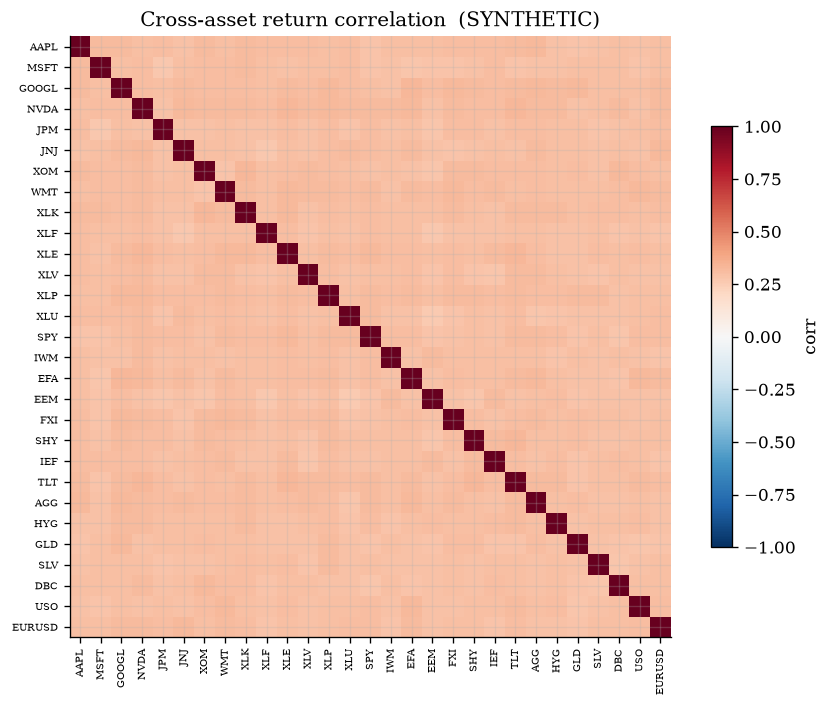

In [7]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7.5, 6))
corr = log_returns.corr()
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=6)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=6)
ax.set_title("Cross-asset return correlation"
             + ("  (SYNTHETIC)" if USING_SYNTHETIC else ""))
fig.colorbar(im, ax=ax, shrink=0.7, label="corr")
plt.tight_layout(); plt.show()

## Cache the panel for downstream notebooks

We persist prices and returns to `data/cache/` so every later notebook loads
the *same bytes* rather than rebuilding. (On the synthetic path we still cache,
so the repo is runnable; replace with the real panel via
`scripts/build_panel.py` when ready.)

In [8]:
cache = Path.cwd().parent / "data" / "cache"
cache.mkdir(parents=True, exist_ok=True)
prices.to_parquet(cache / "prices_29.parquet")
log_returns.to_parquet(cache / "returns_log_29.parquet")
simple_returns.to_parquet(cache / "returns_simple_29.parquet")
print("cached:", sorted(p.name for p in cache.glob("*.parquet")))

cached: ['prices_29.parquet', 'returns_log_29.parquet', 'returns_simple_29.parquet']


## Takeaways

- The **contract** (universe, dates, frequency, costs, split) lives in one
  place; everything imports it, so the comparison is fair by construction.
- The **Panel** makes look-ahead bias structurally impossible.
- **Universe applicability** is an explicit attribute — equity-factor models
  use the equity sleeve, not the full 29. This is the fix for the
  "Fama-French choked on commodities/FX" problem.
- Real data enters **once** via `scripts/build_panel.py`; a synthetic fallback
  keeps the repo runnable for review.

**Next:** `01_mean_variance.ipynb` — the Markowitz core (GMV + tangency), the
model every later method is measured against.